<a href="https://colab.research.google.com/github/Saiakashaya/DATA_SCIENCE/blob/main/ML_DECISION_TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install kaggle

In [21]:
!kaggle datasets download lykin22/drug-data

Dataset URL: https://www.kaggle.com/datasets/lykin22/drug-data
License(s): copyright-authors
100% 1.69k/1.69k [00:00<00:00, 3.39MB/s]



In [22]:
ls-ltr /content

total 773944
-rw-r--r-- 1 root root     23867 Sep 20  2019 airports.csv
-rw-r--r-- 1 root root       359 Sep 20  2019 airlines.csv
-rw-r--r-- 1 root root 592406591 Sep 20  2019 flights.csv
-rw-r--r-- 1 root root 200067268 Sep 20  2019 flight-delays.zip
-rw-r--r-- 1 root root      1728 Apr 19  2021 drug-data.zip
drwxr-xr-x 1 root root      4096 Jun  4 13:32 sample_data/


In [23]:
!unzip drug-data.zip

Archive:  drug-data.zip
  inflating: drug200.csv             


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
data = pd.read_csv("drug200.csv")
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [43]:
data.loc[0]

,0
Age,23.000
Sex,0.000
BP,0.000
Cholesterol,0.000
Na_to_K,25.355
Drug,4.000


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])
X = data.drop('Drug', axis=1)
y = data['Drug']
print(X)

     Age  Sex  BP  Cholesterol  Na_to_K
0     23    0   0            0   25.355
1     47    1   1            0   13.093
2     47    1   1            0   10.114
3     28    0   2            0    7.798
4     61    0   1            0   18.043
..   ...  ...  ..          ...      ...
195   56    0   1            0   11.567
196   16    1   1            0   12.006
197   52    1   2            0    9.894
198   23    1   2            1   14.020
199   40    0   1            1   11.349

[200 rows x 5 columns]


In [36]:
print(data.isnull().sum())

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64


In [37]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

In [38]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB
None


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [40]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [42]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9833333333333333

Confusion Matrix:
[[ 7  0  0  0  0]
 [ 1  4  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 16  0]
 [ 0  0  0  0 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



In [47]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

feature_names = ['Age','Sex','BP','Cholesterol','Na_to_K']
user_data_input = []
for feature in feature_names:
    value = input(f"Enter {feature}: ")
    user_data_input.append(value)

new_patient_df = pd.DataFrame([user_data_input], columns=feature_names)
sex_mapping = {'F': 0, 'M': 1}
if 'Sex' in new_patient_df.columns:
    new_patient_df['Sex'] = new_patient_df['Sex'].map(sex_mapping)
bp_mapping = {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}
if 'BP' in new_patient_df.columns:
    new_patient_df['BP'] = new_patient_df['BP'].map(bp_mapping)
cholesterol_mapping = {'HIGH': 0, 'NORMAL': 1}
if 'Cholesterol' in new_patient_df.columns:
    new_patient_df['Cholesterol'] = new_patient_df['Cholesterol'].map(cholesterol_mapping)
new_patient_df['Age'] = pd.to_numeric(new_patient_df['Age'])
new_patient_df['Na_to_K'] = pd.to_numeric(new_patient_df['Na_to_K'])

if 'X' in globals() and isinstance(X, pd.DataFrame):
    new_patient_df = new_patient_df[X.columns]
else:
    print("Warning: X (training features) DataFrame not found or not a DataFrame type. Skipping column order enforcement.")
prediction_encoded = model.predict(new_patient_df)
predicted_drug = "Unknown"
if 'le' in globals() and isinstance(le, LabelEncoder):
    try:
        predicted_drug = le.inverse_transform(prediction_encoded)[0]
    except ValueError:
        predicted_drug = f"Encoded Drug: {prediction_encoded[0]} (Inverse transform failed)"
    print(f"Predicted Drug: {predicted_drug}")
else:
    print(f"Predicted Drug (encoded value): {prediction_encoded[0]} - Inverse transform not available.")

print("\nProcessed new patient data for prediction:")
print(new_patient_df)

Enter Age: 23
Enter Sex: 1
Enter BP: 2
Enter Cholesterol: 3
Enter Na_to_K: 23.5
Predicted Drug: drugY

Processed new patient data for prediction:
   Age  Sex  BP  Cholesterol  Na_to_K
0   23  NaN NaN          NaN     23.5


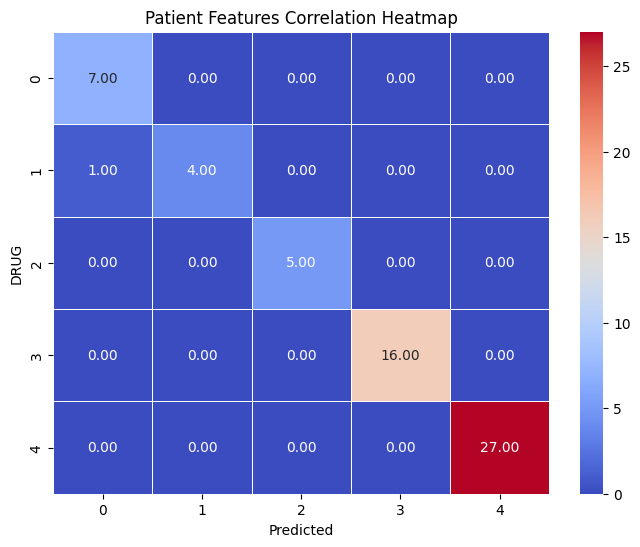

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt=".2f",cmap='coolwarm', linewidths=0.5)
plt.xlabel("Predicted")
plt.ylabel("DRUG")
plt.title("Patient Features Correlation Heatmap")
plt.show()